In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv('datasets/12. Seaborn_Batsman.csv')

In [3]:
data

,RunsScored,BallsFaced,BattingPosition,Dismissal,Inning,Opposition,Year
0,12,22,2,LBW,1,Sri Lanka,2008
1,37,67,2,Caught,2,Sri Lanka,2008
2,25,38,1,Run out,1,Sri Lanka,2008
3,54,66,1,Bowled,1,Sri Lanka,2008
4,31,46,1,LBW,2,Sri Lanka,2008
...,...,...,...,...,...,...,...
203,140,107,3,Stumped,2,West Indies,2018
204,157,129,3,NO,1,West Indies,2018
205,107,119,3,Bowled,2,West Indies,2018
206,16,17,3,Caught,1,West Indies,2018


# Information about the data -

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   RunsScored       208 non-null    int64 
 1   BallsFaced       208 non-null    int64 
 2   BattingPosition  208 non-null    int64 
 3   Dismissal        208 non-null    object
 4   Inning           208 non-null    int64 
 5   Opposition       208 non-null    object
 6   Year             208 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 11.5+ KB


# Statistical Description -

In [5]:
data.describe()

,RunsScored,BallsFaced,BattingPosition,Inning,Year
count,208.000000,208.000000,208.000000,208.000000,208.000000
mean,49.192308,52.961538,3.264423,1.567308,2013.240385
std,43.797641,39.850548,0.781602,0.496644,2.750477
min,0.000000,0.000000,1.000000,1.000000,2008.000000
25%,10.750000,18.000000,3.000000,1.000000,2011.000000
50%,35.000000,46.500000,3.000000,2.000000,2013.000000
75%,81.250000,83.250000,3.000000,2.000000,2015.000000
max,183.000000,159.000000,7.000000,2.000000,2018.000000


# Checking the data for NaN values -

In [6]:
data.isnull().sum()

RunsScored         0
BallsFaced         0
BattingPosition    0
Dismissal          0
Inning             0
Opposition         0
Year               0
dtype: int64

# EDA using matplotlib -

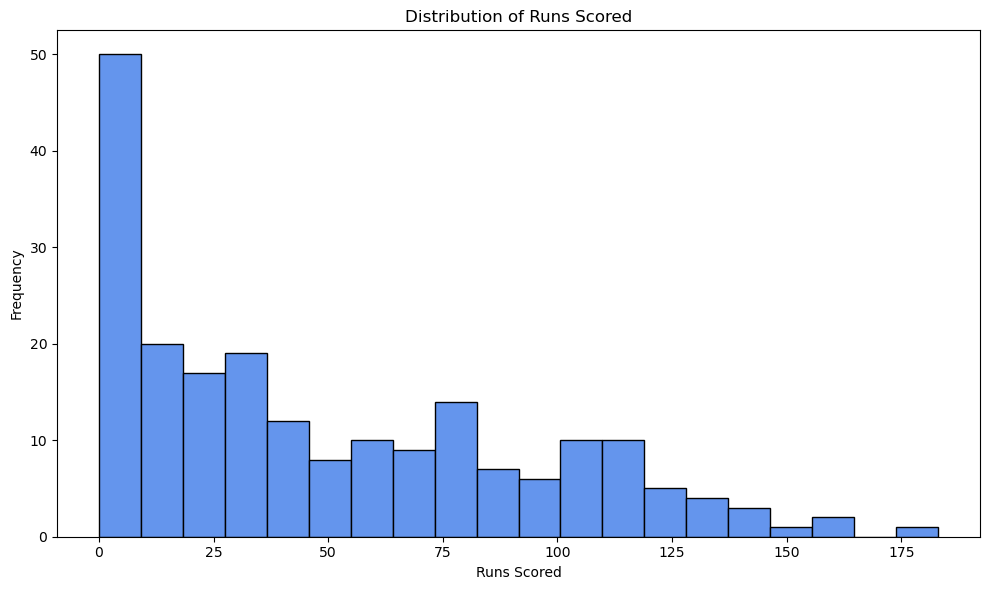

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(
    data['RunsScored'],
    bins=20,
    color='cornflowerblue',
    edgecolor='black'
)
plt.title('Distribution of Runs Scored')
plt.xlabel('Runs Scored')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


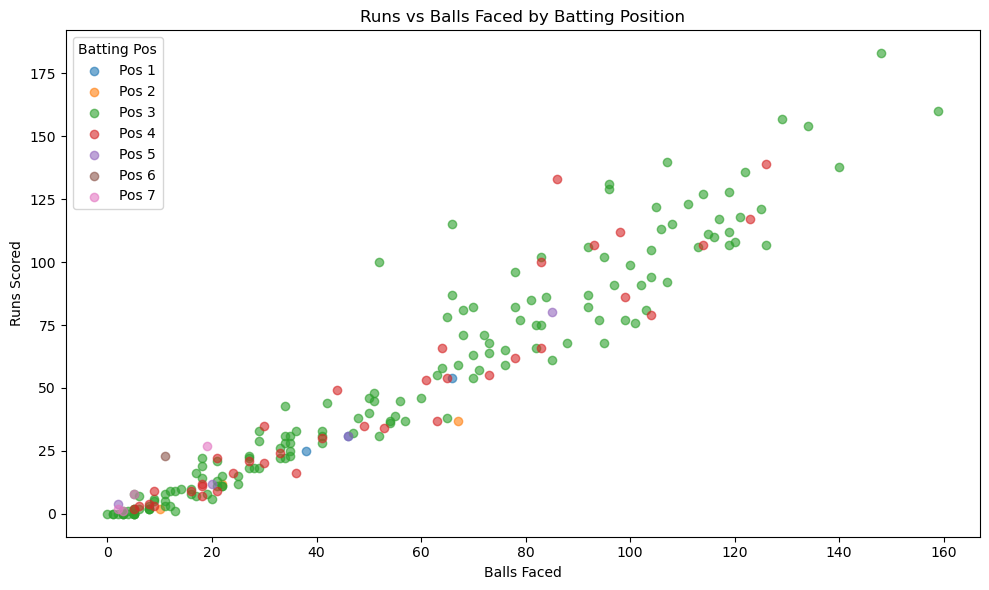

In [11]:
plt.figure(figsize=(10, 6))
for pos in sorted(data['BattingPosition'].unique()):
    subset = data[data['BattingPosition'] == pos]
    plt.scatter(
        subset['BallsFaced'],
        subset['RunsScored'],
        alpha=0.6,
        label=f'Pos {pos}'
    )
plt.title('Runs vs Balls Faced by Batting Position')
plt.xlabel('Balls Faced')
plt.ylabel('Runs Scored')
plt.legend(title='Batting Pos')
plt.tight_layout()
plt.show()

C:\Users\yatha\AppData\Local\Temp\ipykernel_4404\983884741.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


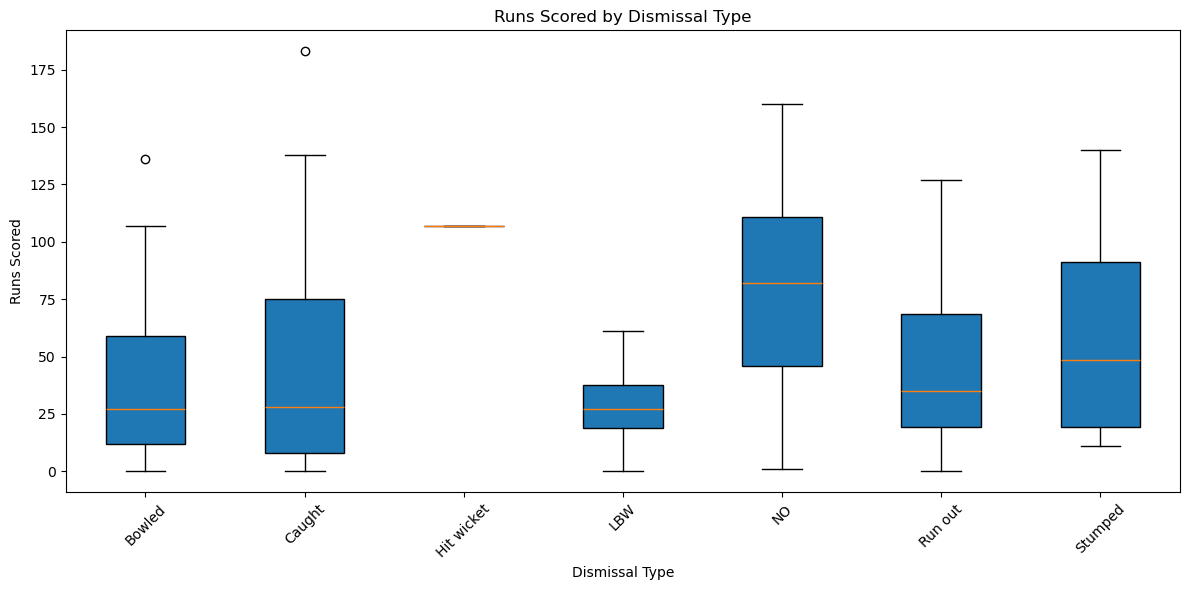

In [17]:
dismissal_groups = data.groupby('Dismissal')['RunsScored'].apply(list)
plt.figure(figsize=(12, 6))
plt.boxplot(
    dismissal_groups,
    labels=dismissal_groups.index,
    patch_artist=True
)
plt.title('Runs Scored by Dismissal Type')
plt.xlabel('Dismissal Type')
plt.ylabel('Runs Scored')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

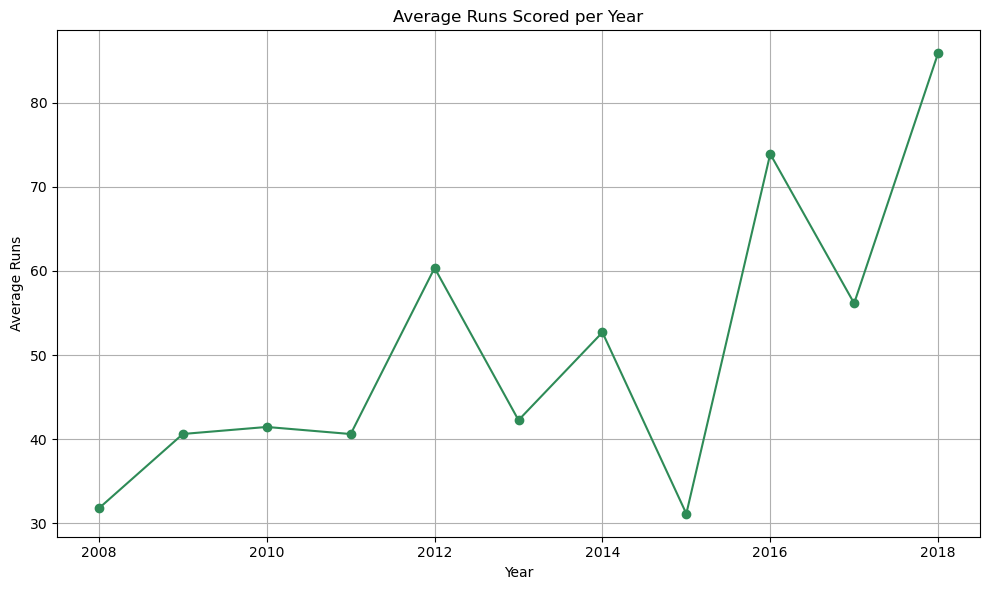

In [20]:
avg_runs_year = data.groupby('Year')['RunsScored'].mean()
plt.figure(figsize=(10, 6))
plt.plot(
    avg_runs_year.index,
    avg_runs_year.values,
    marker='o',
    linestyle='-',
    color='seagreen'
)
plt.title('Average Runs Scored per Year')
plt.xlabel('Year')
plt.ylabel('Average Runs')
plt.grid(True)
plt.tight_layout()
plt.show()

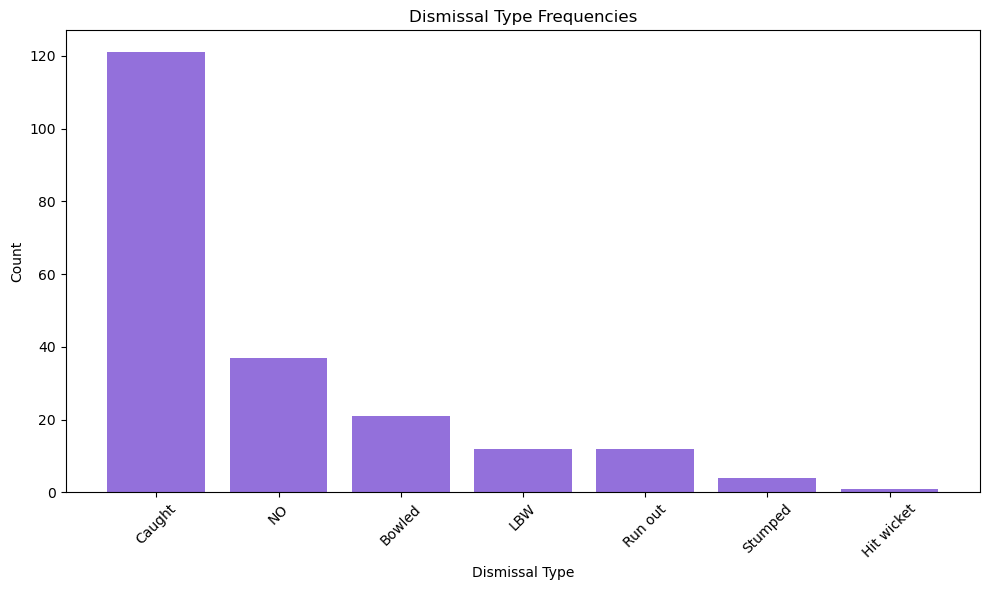

In [22]:
dismissal_counts = data['Dismissal'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(
    dismissal_counts.index,
    dismissal_counts.values,
    color='mediumpurple'
)
plt.title('Dismissal Type Frequencies')
plt.xlabel('Dismissal Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

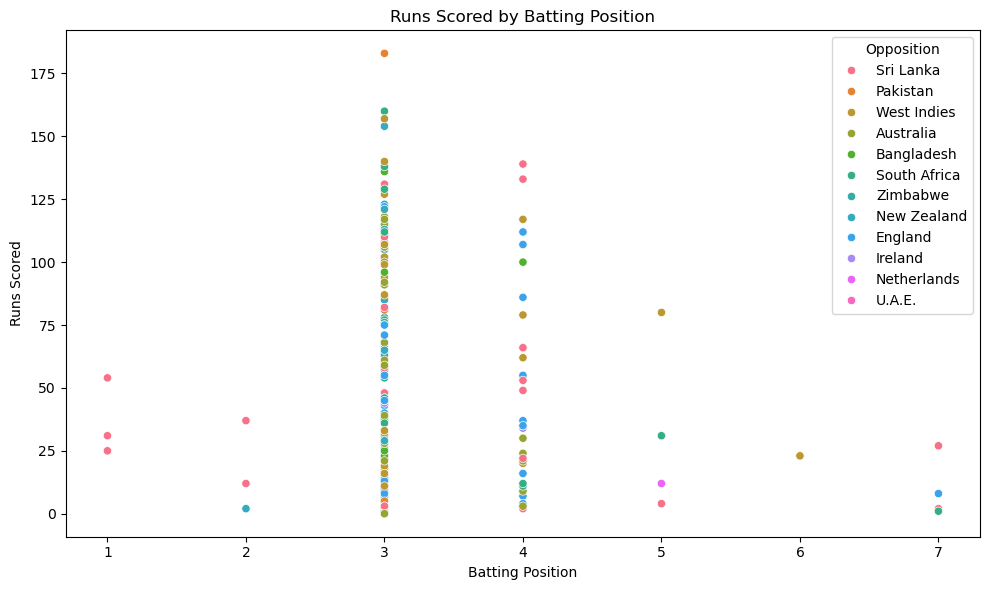

In [62]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='BattingPosition', y='RunsScored', hue='Opposition')
plt.title('Runs Scored by Batting Position')
plt.xlabel('Batting Position')
plt.ylabel('Runs Scored')
plt.tight_layout()
plt.show()

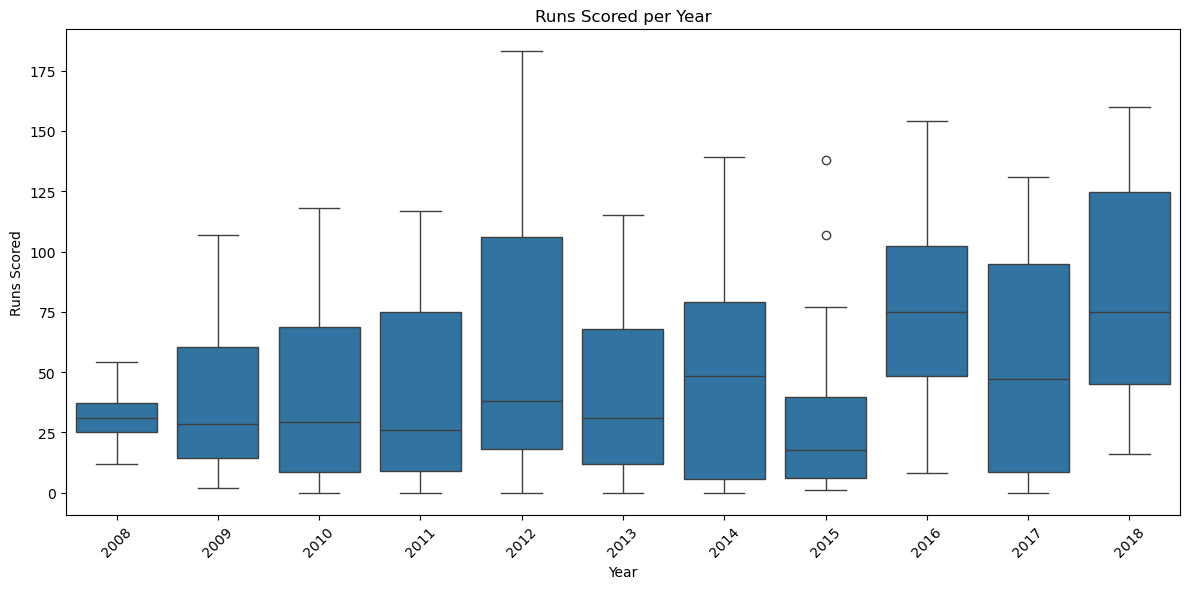

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Year', y='RunsScored')
plt.title('Runs Scored per Year')
plt.xlabel('Year')
plt.ylabel('Runs Scored')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

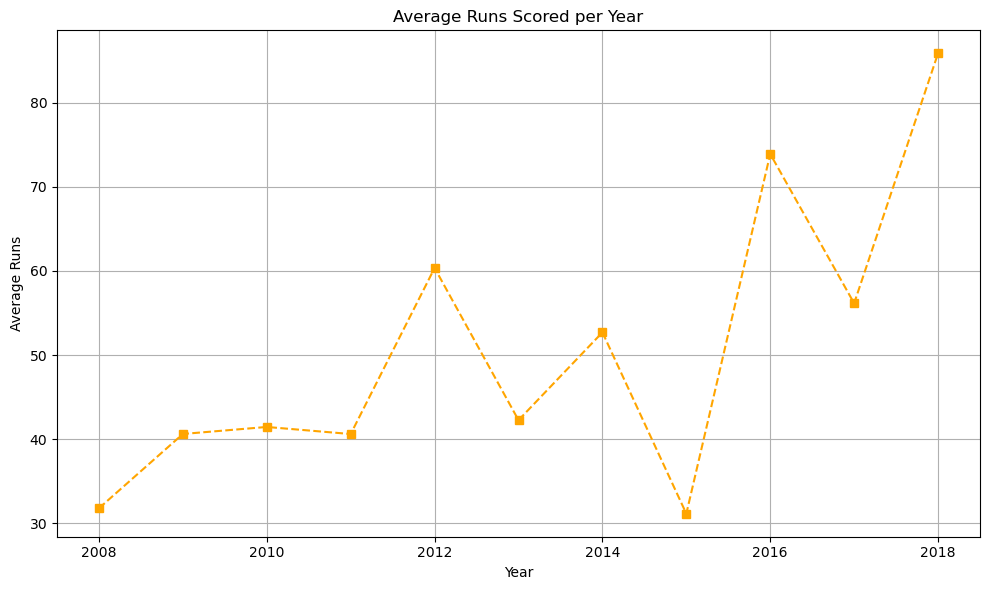

In [66]:
avg_runs_per_year = data.groupby('Year')['RunsScored'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(avg_runs_per_year['Year'], avg_runs_per_year['RunsScored'], marker='s', linestyle='--', color='orange')
plt.title('Average Runs Scored per Year')
plt.xlabel('Year')
plt.ylabel('Average Runs')
plt.grid(True)
plt.tight_layout()
plt.show()